In [ ]:
import pandas as pd
import numpy as np
import re
import string
import random
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Download required NLTK resources (only runs once, then cached)
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
random.seed(42)

departments = ["CSE", "ECE", "MCA", "IT", "MECH"]
subjects = ["Data Structures", "Computer Networks", "DBMS", "Operating Systems",
            "Machine Learning", "Software Engineering", "Web Technologies", "Mathematics"]

# Templates written from a student's point of view, tagged with the sentiment they express
positive_templates = [
    "The {subject} classes were very engaging and the {teacher} explained concepts clearly.",
    "I really enjoyed {subject}, the practical sessions helped me understand the theory better.",
    "The {teacher} for {subject} was very supportive and always cleared our doubts patiently.",
    "Loved the way {subject} was taught, real-world examples made it easy to relate to.",
    "{subject} lab sessions were well organized and gave good hands-on experience.",
    "The course material for {subject} was well structured and easy to follow.",
    "Great teaching pace in {subject}, nothing felt rushed and doubts were solved quickly.",
]

negative_templates = [
    "The pace of {subject} classes was too fast, it was hard to keep up with the {teacher}.",
    "We did not get enough practical or lab exposure in {subject}, it was mostly theory.",
    "The {teacher} for {subject} did not explain doubts properly, needs improvement.",
    "Study material for {subject} was insufficient and outdated, needs to be updated.",
    "Too many assignments were given for {subject} without enough time to complete them.",
    "The syllabus for {subject} was not completed on time before exams.",
    "Classroom infrastructure was poor, projector and wifi issues disturbed {subject} classes.",
    "Exam pattern for {subject} did not match what was actually taught in class.",
    "Class timings for {subject} were inconvenient and often clashed with other subjects.",
    "Not enough real-world case studies were discussed in {subject}, felt very theoretical.",
]

neutral_templates = [
    "{subject} classes were okay, some topics were good and some could be improved.",
    "The {teacher} covered the {subject} syllabus but pacing could be better balanced.",
    "{subject} was an average experience, nothing exceptional but nothing bad either.",
]

teachers = ["professor", "faculty", "instructor", "lecturer"]

def make_feedback(template_list, sentiment_label):
    subject = random.choice(subjects)
    dept = random.choice(departments)
    teacher = random.choice(teachers)
    text = random.choice(template_list).format(subject=subject, teacher=teacher)
    rating = {
        "Positive": random.choice([4, 5]),
        "Negative": random.choice([1, 2]),
        "Neutral": 3,
    }[sentiment_label]
    return {"department": dept, "subject": subject, "feedback": text,
             "rating": rating, "true_sentiment": sentiment_label}

records = []
for _ in range(90):
    records.append(make_feedback(positive_templates, "Positive"))
for _ in range(90):
    records.append(make_feedback(negative_templates, "Negative"))
for _ in range(30):
    records.append(make_feedback(neutral_templates, "Neutral"))

random.shuffle(records)
df = pd.DataFrame(records).reset_index(drop=True)
df["student_id"] = ["S" + str(i+1).zfill(3) for i in range(len(df))]
df = df[["student_id", "department", "subject", "feedback", "rating", "true_sentiment"]]

df.to_csv("student_feedback_raw.csv", index=False)
print(f"Collected {len(df)} feedback records across {df['department'].nunique()} departments")
df.head()

Collected 210 feedback records across 5 departments


,student_id,department,subject,feedback,rating,true_sentiment
0,S001,MCA,DBMS,DBMS lab sessions were well organized and gave...,4,Positive
1,S002,CSE,Computer Networks,"I really enjoyed Computer Networks, the practi...",4,Positive
2,S003,MCA,Operating Systems,"I really enjoyed Operating Systems, the practi...",5,Positive
3,S004,MCA,Machine Learning,"Machine Learning was an average experience, no...",3,Neutral
4,S005,MCA,Computer Networks,The Computer Networks classes were very engagi...,4,Positive


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Keep a few negation words - they matter a lot for sentiment ("not", "no", "n't")
stop_words -= {"not", "no", "nor"}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # remove punctuation/numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

df["tokens"] = df["feedback"].apply(clean_text)
df["clean_feedback"] = df["tokens"].apply(lambda toks: " ".join(toks))

print("Example of preprocessing:\n")
print("Original :", df.loc[0, "feedback"])
print("Cleaned  :", df.loc[0, "clean_feedback"])
df[["feedback", "clean_feedback"]].head()

Example of preprocessing:

Original : DBMS lab sessions were well organized and gave good hands-on experience.
Cleaned  : dbms lab session well organized gave good hand experience


,feedback,clean_feedback
0,DBMS lab sessions were well organized and gave...,dbms lab session well organized gave good hand...
1,"I really enjoyed Computer Networks, the practi...",really enjoyed computer network practical sess...
2,"I really enjoyed Operating Systems, the practi...",really enjoyed operating system practical sess...
3,"Machine Learning was an average experience, no...",machine learning average experience nothing ex...
4,The Computer Networks classes were very engagi...,computer network class engaging instructor exp...


In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    vader_score = sia.polarity_scores(text)["compound"]
    blob_score = TextBlob(text).sentiment.polarity
    # average the two scores for a more robust estimate
    combined = (vader_score + blob_score) / 2

    if combined >= 0.15:
        label = "Positive"
    elif combined <= -0.15:
        label = "Negative"
    else:
        label = "Neutral"
    return pd.Series([vader_score, blob_score, combined, label])

df[["vader_score", "textblob_score", "combined_score", "predicted_sentiment"]] = \
    df["feedback"].apply(get_sentiment)

df[["feedback", "vader_score", "textblob_score", "predicted_sentiment"]].head()

,feedback,vader_score,textblob_score,predicted_sentiment
0,DBMS lab sessions were well organized and gave...,0.6124,0.700000,Positive
1,"I really enjoyed Computer Networks, the practi...",0.7574,0.500000,Positive
2,"I really enjoyed Operating Systems, the practi...",0.7574,0.500000,Positive
3,"Machine Learning was an average experience, no...",0.5824,-0.061111,Positive
4,The Computer Networks classes were very engagi...,0.6590,0.310000,Positive


Sentiment classification accuracy vs simulated ground truth: 56.2%

Sentiment distribution:
 predicted_sentiment
Positive    128
Neutral      54
Negative     28
Name: count, dtype: int64


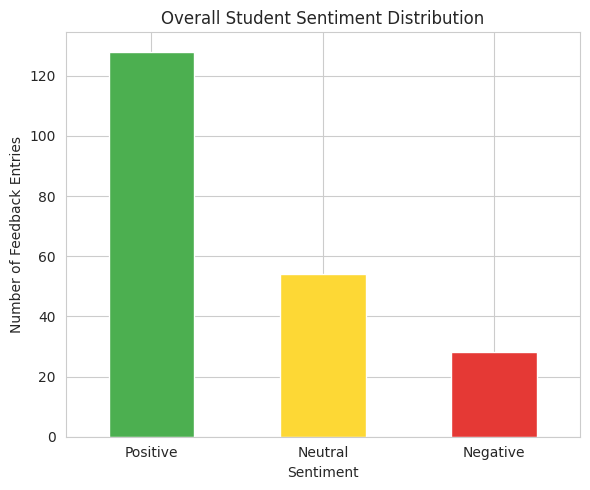

In [ ]:
# How well does our automated sentiment match the (simulated) ground truth?
accuracy = (df["predicted_sentiment"] == df["true_sentiment"]).mean()
print(f"Sentiment classification accuracy vs simulated ground truth: {accuracy:.1%}")

sentiment_counts = df["predicted_sentiment"].value_counts()
print("\nSentiment distribution:\n", sentiment_counts)

plt.figure(figsize=(6,5))
colors = {"Positive": "#4CAF50", "Negative": "#E53935", "Neutral": "#FDD835"}
sentiment_counts.reindex(["Positive", "Neutral", "Negative"]).plot(
    kind="bar", color=[colors[s] for s in ["Positive", "Neutral", "Negative"]])
plt.title("Overall Student Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Entries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=120)
plt.show()

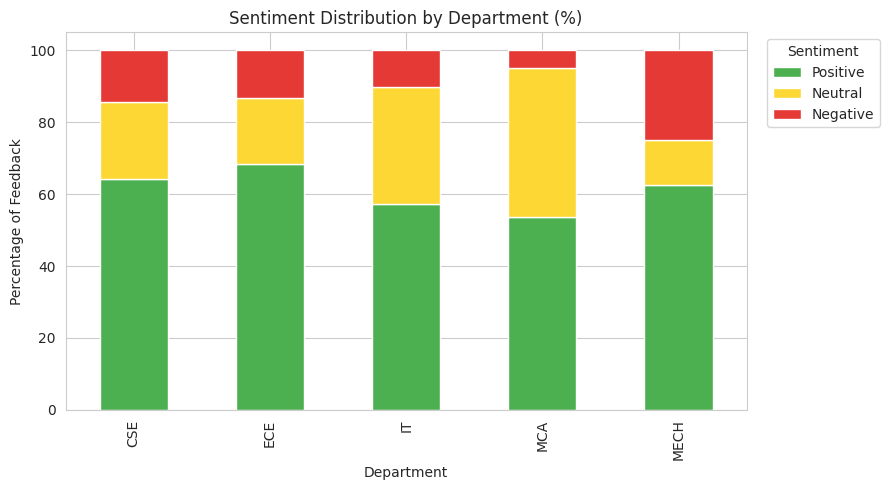

In [ ]:
# Sentiment breakdown by department - helps admin see which departments need attention
dept_sentiment = pd.crosstab(df["department"], df["predicted_sentiment"], normalize="index") * 100

dept_sentiment[["Positive", "Neutral", "Negative"]].plot(
    kind="bar", stacked=True, color=["#4CAF50", "#FDD835", "#E53935"], figsize=(9,5))
plt.title("Sentiment Distribution by Department (%)")
plt.ylabel("Percentage of Feedback")
plt.xlabel("Department")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("sentiment_by_department.png", dpi=120)
plt.show()

Top keywords in negative/neutral feedback:
  not             41
  enough          36
  class           29
  study           22
  time            21
  exam            16
  data            16
  structure       16
  real            15
  world           15
  case            15
  discussed       15
  felt            15
  theoretical     15
  mathematics     14


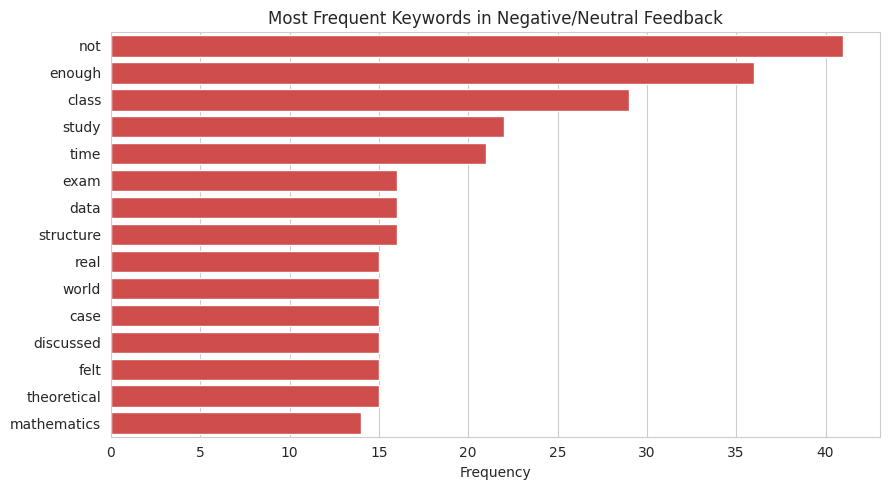

In [ ]:
negative_feedback = df[df["predicted_sentiment"].isin(["Negative", "Neutral"])]
all_tokens = [tok for toks in negative_feedback["tokens"] for tok in toks]

word_freq = Counter(all_tokens)
top_words = word_freq.most_common(15)
print("Top keywords in negative/neutral feedback:")
for word, count in top_words:
    print(f"  {word:15s} {count}")

plt.figure(figsize=(9,5))
words, counts = zip(*top_words)
sns.barplot(x=list(counts), y=list(words), color="#E53935")
plt.title("Most Frequent Keywords in Negative/Neutral Feedback")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig("top_keywords.png", dpi=120)
plt.show()

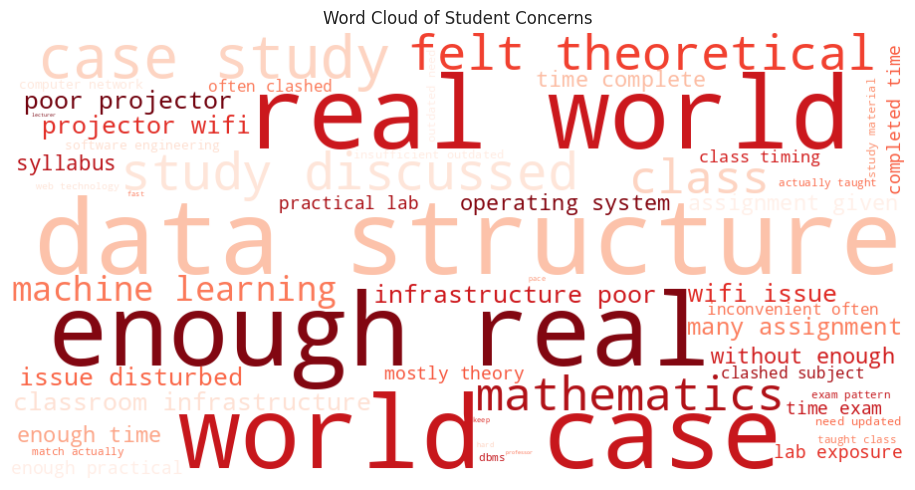

In [ ]:
# Word cloud gives administration a quick visual snapshot of common complaints
wc_text = " ".join(all_tokens)
wordcloud = WordCloud(width=900, height=450, background_color="white",
                       colormap="Reds", max_words=60).generate(wc_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Student Concerns")
plt.tight_layout()
plt.savefig("concerns_wordcloud.png", dpi=120)
plt.show()

In [ ]:
# Bigrams (two-word phrases) often capture concerns better than single words
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english", max_features=15)
bigram_matrix = vectorizer.fit_transform(negative_feedback["clean_feedback"])
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_freq = sorted(zip(vectorizer.get_feature_names_out(), bigram_counts),
                      key=lambda x: x[1], reverse=True)

print("Top recurring phrases in negative/neutral feedback:")
for phrase, count in bigram_freq[:10]:
    print(f"  {phrase:25s} {count}")

Top recurring phrases in negative/neutral feedback:
  data structure            16
  case study                15
  felt theoretical          15
  real world                15
  study discussed           15
  world case                15
  machine learning          14
  classroom infrastructure  12
  infrastructure poor       12
  issue disturbed           12


In [ ]:
# Rule-based concern categorization: maps keywords to a concern category
# This turns raw text into actionable buckets for the administration
concern_keywords = {
    "Teaching Pace": ["pace", "fast", "rushed", "slow", "quickly", "keep"],
    "Practical/Lab Exposure": ["practical", "lab", "hand", "hands", "real", "world", "case", "study"],
    "Faculty Support": ["doubt", "explain", "clear", "support", "patient", "teacher", "professor",
                          "faculty", "instructor", "lecturer"],
    "Study Material": ["material", "outdated", "insufficient", "resource", "note", "book"],
    "Workload/Assignments": ["assignment", "workload", "time", "much", "many"],
    "Syllabus Coverage": ["syllabus", "complete", "cover", "exam", "pattern"],
    "Infrastructure": ["infrastructure", "projector", "wifi", "classroom", "facility"],
    "Scheduling": ["timing", "schedule", "clash", "inconvenient"],
}

def categorize(tokens):
    hits = []
    token_set = set(tokens)
    for category, keywords in concern_keywords.items():
        if token_set & set(keywords):
            hits.append(category)
    return hits

negative_feedback = negative_feedback.copy()
negative_feedback["concern_categories"] = negative_feedback["tokens"].apply(categorize)

category_counts = Counter(
    cat for cats in negative_feedback["concern_categories"] for cat in cats
)
concern_summary = pd.DataFrame(category_counts.most_common(),
                                 columns=["Concern Category", "Mentions"])
concern_summary["% of Negative Feedback"] = (
    concern_summary["Mentions"] / len(negative_feedback) * 100
).round(1)
concern_summary

,Concern Category,Mentions,% of Negative Feedback
0,Practical/Lab Exposure,32,39.0
1,Syllabus Coverage,27,32.9
2,Workload/Assignments,21,25.6
3,Infrastructure,12,14.6
4,Scheduling,9,11.0
5,Study Material,7,8.5
6,Teaching Pace,2,2.4
7,Faculty Support,2,2.4


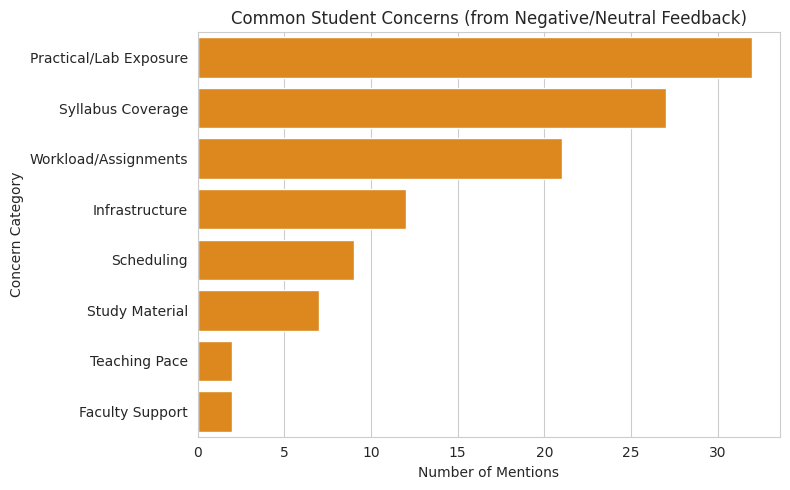

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=concern_summary, x="Mentions", y="Concern Category", color="#FB8C00")
plt.title("Common Student Concerns (from Negative/Neutral Feedback)")
plt.xlabel("Number of Mentions")
plt.tight_layout()
plt.savefig("concern_categories.png", dpi=120)
plt.show()

## 5. Prepare Improvement Suggestions

Finally, we map each identified concern category to a concrete, actionable improvement suggestion.
This is the output the administration actually needs — a short, prioritized action list.

In [ ]:
suggestion_map = {
    "Teaching Pace": "Encourage faculty to balance the teaching pace, add buffer/revision "
                      "classes for difficult topics, and collect mid-semester pace feedback.",
    "Practical/Lab Exposure": "Increase the ratio of practical/lab sessions to theory, and "
                               "include more real-world case studies and mini-projects.",
    "Faculty Support": "Conduct faculty development workshops on doubt-clearing techniques "
                        "and consider dedicated weekly doubt-clearing sessions.",
    "Study Material": "Regularly update study material/notes and provide curated reference "
                       "resources aligned with the current syllabus.",
    "Workload/Assignments": "Review assignment load across subjects to avoid clustering "
                             "deadlines, and give students adequate submission time.",
    "Syllabus Coverage": "Introduce syllabus-tracking checkpoints so faculty can pace content "
                          "delivery to finish before exams, with revision buffer weeks.",
    "Infrastructure": "Audit and upgrade classroom infrastructure (projectors, Wi-Fi, seating) "
                       "each semester before classes begin.",
    "Scheduling": "Review the timetable for clashes and inconvenient slots when preparing the "
                  "next semester's schedule.",
}

# Rank concerns by how often students mentioned them
ranked_concerns = concern_summary.sort_values("Mentions", ascending=False)

print("=" * 70)
print("PRIORITIZED IMPROVEMENT SUGGESTIONS FOR ADMINISTRATION")
print("=" * 70)
for i, row in ranked_concerns.iterrows():
    category = row["Concern Category"]
    print(f"\n{ranked_concerns.index.get_loc(i)+1}. {category} "
          f"({row['Mentions']} mentions, {row['% of Negative Feedback']}% of negative feedback)")
    print(f"   Suggestion: {suggestion_map[category]}")

PRIORITIZED IMPROVEMENT SUGGESTIONS FOR ADMINISTRATION

1. Practical/Lab Exposure (32 mentions, 39.0% of negative feedback)
   Suggestion: Increase the ratio of practical/lab sessions to theory, and include more real-world case studies and mini-projects.

2. Syllabus Coverage (27 mentions, 32.9% of negative feedback)
   Suggestion: Introduce syllabus-tracking checkpoints so faculty can pace content delivery to finish before exams, with revision buffer weeks.

3. Workload/Assignments (21 mentions, 25.6% of negative feedback)
   Suggestion: Review assignment load across subjects to avoid clustering deadlines, and give students adequate submission time.

4. Infrastructure (12 mentions, 14.6% of negative feedback)
   Suggestion: Audit and upgrade classroom infrastructure (projectors, Wi-Fi, seating) each semester before classes begin.

5. Scheduling (9 mentions, 11.0% of negative feedback)
   Suggestion: Review the timetable for clashes and inconvenient slots when preparing the next semest

In [ ]:
total = len(df)
pos_pct = (df["predicted_sentiment"] == "Positive").mean() * 100
neg_pct = (df["predicted_sentiment"] == "Negative").mean() * 100
neu_pct = (df["predicted_sentiment"] == "Neutral").mean() * 100
avg_rating = df["rating"].mean()

top3_concerns = ranked_concerns.head(3)["Concern Category"].tolist()

report = f"""
STUDENT FEEDBACK ANALYSIS - SUMMARY REPORT
{'='*50}
Total feedback records analyzed : {total}
Average rating (out of 5)        : {avg_rating:.2f}

Sentiment Overview:
  Positive : {pos_pct:.1f}%
  Neutral  : {neu_pct:.1f}%
  Negative : {neg_pct:.1f}%

Top 3 concerns raised by students:
  1. {top3_concerns[0]}
  2. {top3_concerns[1]}
  3. {top3_concerns[2]}

Recommended immediate actions:
  - {suggestion_map[top3_concerns[0]]}
  - {suggestion_map[top3_concerns[1]]}
  - {suggestion_map[top3_concerns[2]]}
"""
print(report)

with open("feedback_analysis_summary.txt", "w") as f:
    f.write(report)

# Save the fully processed dataset with sentiment + concern labels for record-keeping
df.to_csv("student_feedback_analyzed.csv", index=False)
print("Saved: student_feedback_analyzed.csv, feedback_analysis_summary.txt")


STUDENT FEEDBACK ANALYSIS - SUMMARY REPORT
Total feedback records analyzed : 210
Average rating (out of 5)        : 2.99

Sentiment Overview:
  Positive : 61.0%
  Neutral  : 25.7%
  Negative : 13.3%

Top 3 concerns raised by students:
  1. Practical/Lab Exposure
  2. Syllabus Coverage
  3. Workload/Assignments

Recommended immediate actions:
  - Increase the ratio of practical/lab sessions to theory, and include more real-world case studies and mini-projects.
  - Introduce syllabus-tracking checkpoints so faculty can pace content delivery to finish before exams, with revision buffer weeks.
  - Review assignment load across subjects to avoid clustering deadlines, and give students adequate submission time.

Saved: student_feedback_analyzed.csv, feedback_analysis_summary.txt
